In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
df = pd.read_csv('../data/telco_churn_cleaned.csv')

In [3]:
# Convert all text columns to numbers (One-Hot Encoding)
df_model = pd.get_dummies(df, drop_first=True)

In [4]:
# Separate features (X) and target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

In [5]:
# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
print("Training rows:", X_train.shape[0]) 
print("Testing rows:", X_test.shape[0])   

Training rows: 5634
Testing rows: 1409


In [7]:
# Build the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
# Test the model
y_pred = model.predict(X_test)

In [9]:
# See results
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred), 2))

              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.65      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score: 0.69


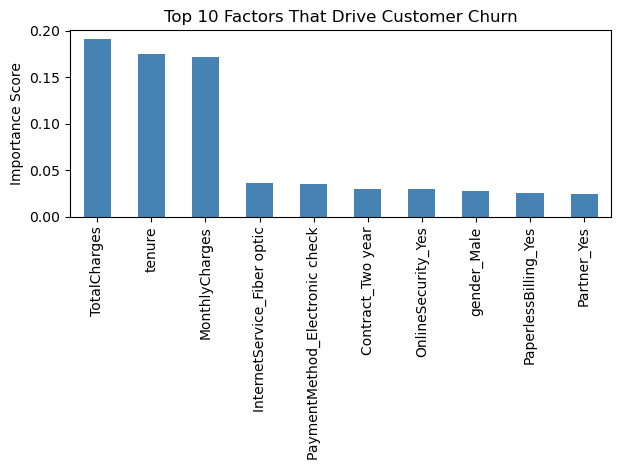

In [10]:
# Which factors matter most? (Feature Importance)
import matplotlib.pyplot as plt

importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances[:10].plot(kind='bar', color='steelblue')
plt.title('Top 10 Factors That Drive Customer Churn')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('../visuals/feature_importance.png')
plt.show()

In [11]:
results = X_test.copy()
results['Actual_Churn'] = y_test.values
results['Predicted_Churn'] = y_pred
results['Churn_Probability'] = model.predict_proba(X_test)[:,1]

results.to_csv('../data/churn_predictions.csv', index=False)
print("✅ Ready to import into Power BI!")

✅ Ready to import into Power BI!
